# Extending ggplot2_py

Ported from R vignette [`extending-ggplot2.qmd`](https://ggplot2.tidyverse.org/articles/extending-ggplot2.html).

This vignette documents the extension mechanism: how to create
custom Stats, Geoms, and Themes using the ggproto class system.

In [1]:
from ggplot2_py import *
from ggplot2_py.plot import GGPlot
from ggplot2_py.stat import Stat
from ggplot2_py.geom import Geom
from ggplot2_py.layer import layer as Layer
from ggplot2_py.datasets import mpg
import pandas as pd
import numpy as np

GGPlot.fig_width = 7
GGPlot.fig_height = 5
GGPlot.fig_dpi = 96

## Creating a new stat

Stats are an important part of layers: they instruct *what* is displayed,
not *how*. The two most important components are `compute_group()` and
`required_aes`.

### The simplest stat: convex hull

R equivalent:
```r
StatChull <- ggproto("StatChull", Stat,
  compute_group = function(data, scales) {
    data[chull(data$x, data$y), , drop = FALSE]
  },
  required_aes = c("x", "y")
)
```

In [2]:
from scipy.spatial import ConvexHull

class StatChull(Stat):
    """Compute the convex hull of a set of points."""
    required_aes = ['x', 'y']

    def compute_group(self, data, scales, **kwargs):
        pts = data[['x', 'y']].values
        if len(pts) < 3:
            return data
        hull = ConvexHull(pts)
        idx = np.append(hull.vertices, hull.vertices[0])
        return data.iloc[idx].reset_index(drop=True)


def stat_chull(mapping=None, data=None, geom='polygon', position='identity',
               na_rm=False, show_legend=None, inherit_aes=True, **kwargs):
    """Layer wrapper for StatChull."""
    return Layer(
        stat=StatChull, geom=geom, data=data, mapping=mapping,
        position=position, show_legend=show_legend,
        inherit_aes=inherit_aes, params={'na_rm': na_rm, **kwargs},
    )

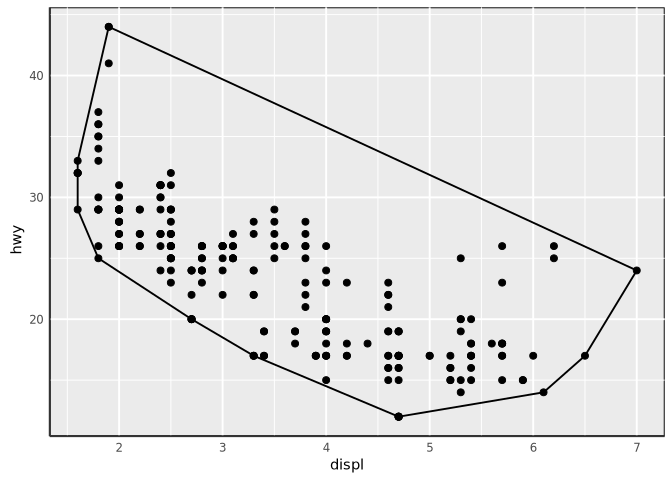

In [3]:
# Basic convex hull
ggplot(mpg, aes('displ', 'hwy')) + geom_point() + stat_chull(fill=None, colour='black')

ggplot2 automatically preserves aesthetics that are constant within each group.
So grouping by colour produces per-group convex hulls:

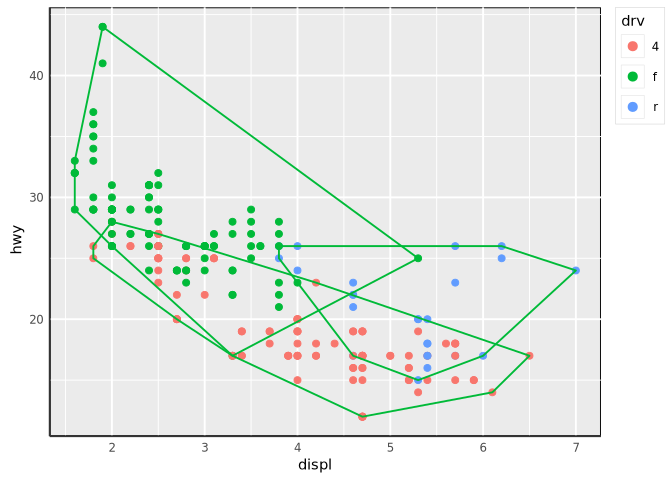

In [4]:
# Per-group hulls coloured by drive train
ggplot(mpg, aes('displ', 'hwy', colour='drv')) + geom_point() + stat_chull(fill=None)

We can override the default geom to display the hull differently:

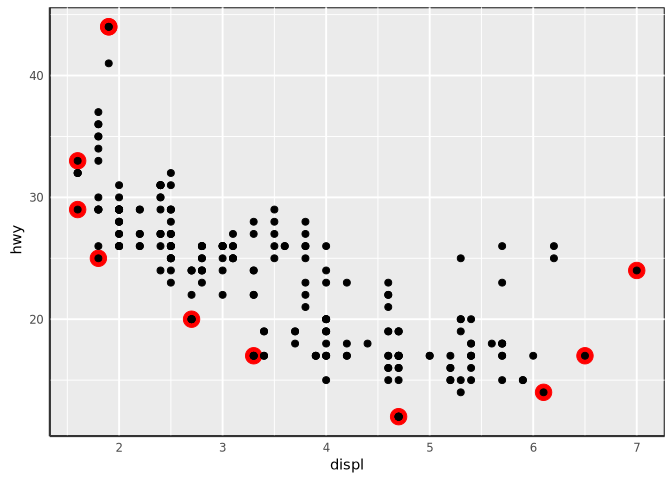

In [5]:
# Hull vertices highlighted as red points
(
    ggplot(mpg, aes('displ', 'hwy'))
    + stat_chull(geom='point', size=4, colour='red')
    + geom_point()
)

### Stat parameters

A more complex stat does computation. Here we implement a simple
`stat_lm()` that fits a linear model and generates a prediction grid.

R equivalent:
```r
StatLm <- ggproto("StatLm", Stat,
  required_aes = c("x", "y"),
  compute_group = function(data, scales, params = list(),
                           n = 100, formula = y ~ x) {
    rng <- range(data$x, na.rm = TRUE)
    grid <- data.frame(x = seq(rng[1], rng[2], length = n))
    mod <- lm(formula, data = data)
    grid$y <- predict(mod, newdata = grid)
    grid
  }
)
```

In [6]:
class StatLm(Stat):
    """Simple linear regression line."""
    required_aes = ['x', 'y']

    def compute_group(self, data, scales, n=100, degree=1, **kwargs):
        x = data['x'].values.astype(float)
        y = data['y'].values.astype(float)
        coeffs = np.polyfit(x, y, degree)
        x_grid = np.linspace(x.min(), x.max(), n)
        y_pred = np.polyval(coeffs, x_grid)
        return pd.DataFrame({'x': x_grid, 'y': y_pred})


def stat_lm(mapping=None, data=None, geom='line', position='identity',
            n=100, degree=1, **kwargs):
    return Layer(
        stat=StatLm, geom=geom, data=data, mapping=mapping,
        position=position, params={'n': n, 'degree': degree, **kwargs},
    )

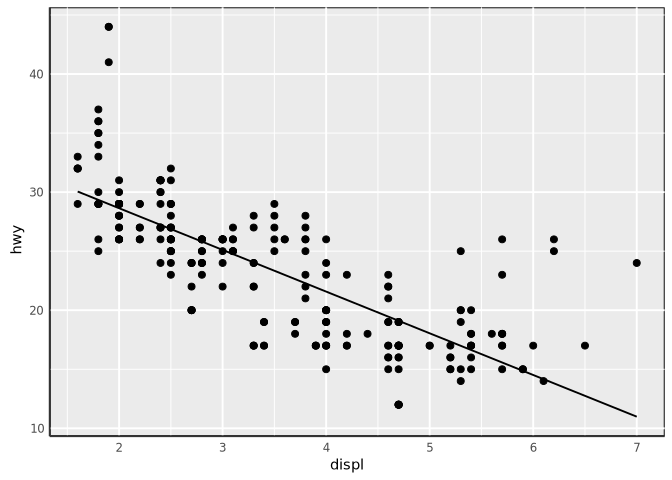

In [7]:
# Simple linear fit
ggplot(mpg, aes('displ', 'hwy')) + geom_point() + stat_lm()

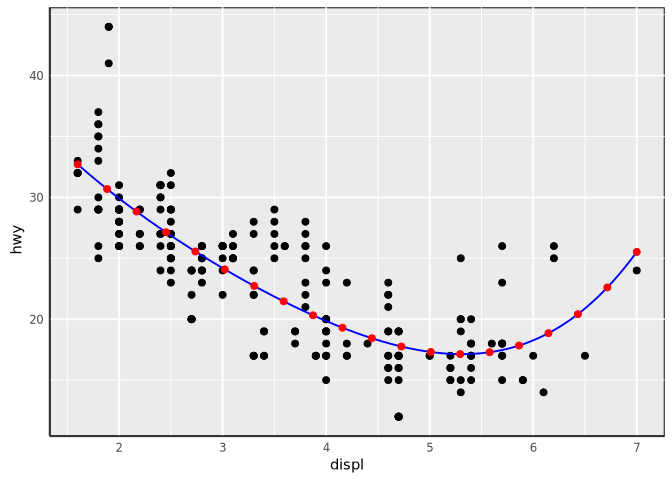

In [8]:
# Polynomial fit (degree=4) with prediction points shown
(
    ggplot(mpg, aes('displ', 'hwy'))
    + geom_point()
    + stat_lm(degree=4, colour='blue')
    + stat_lm(degree=4, geom='point', colour='red', n=20)
)

### Picking defaults with `setup_params`

Sometimes you have calculations that should be performed once for the
complete dataset, not once per group. This is useful for picking sensible
defaults. R uses `setup_params()` for this.

Here we create a density stat that picks one bandwidth for all groups:

In [9]:
from scipy.stats import gaussian_kde

class StatDensityCommon(Stat):
    """Density estimate with a shared bandwidth across groups."""
    required_aes = ['x']

    def setup_params(self, data, params):
        if params.get('bandwidth') is not None:
            return params
        # Pick the mean of per-group optimal bandwidths
        bws = []
        for _, gd in data.groupby('group', observed=True):
            try:
                kde = gaussian_kde(gd['x'].values)
                bws.append(kde.factor * gd['x'].std())
            except Exception:
                pass
        params['bandwidth'] = float(np.mean(bws)) if bws else 1.0
        print(f"Picking bandwidth of {params['bandwidth']:.3f}")
        return params

    def compute_group(self, data, scales, bandwidth=1, n=512, **kwargs):
        x = data['x'].values.astype(float)
        grid = np.linspace(x.min() - 3*bandwidth, x.max() + 3*bandwidth, n)
        kde = gaussian_kde(x, bw_method=bandwidth / x.std() if x.std() > 0 else 1)
        return pd.DataFrame({'x': grid, 'y': kde(grid)})


def stat_density_common(mapping=None, data=None, geom='line',
                        position='identity', bandwidth=None, **kwargs):
    return Layer(
        stat=StatDensityCommon, geom=geom, data=data, mapping=mapping,
        position=position, params={'bandwidth': bandwidth, **kwargs},
    )

Picking bandwidth of 0.383


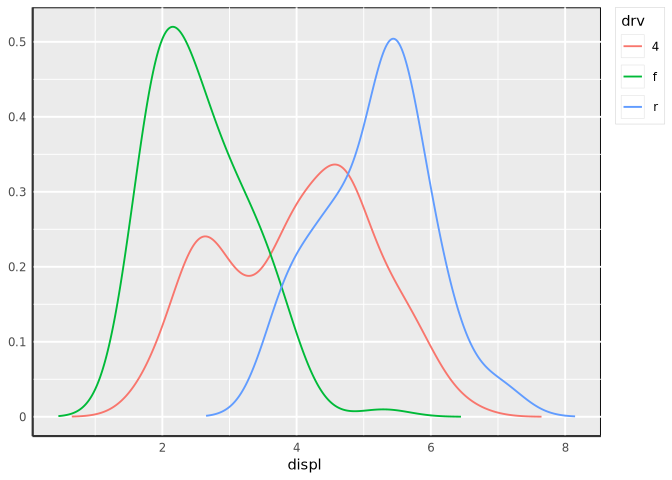

In [10]:
# Auto-picked bandwidth
ggplot(mpg, aes('displ', colour='drv')) + stat_density_common()

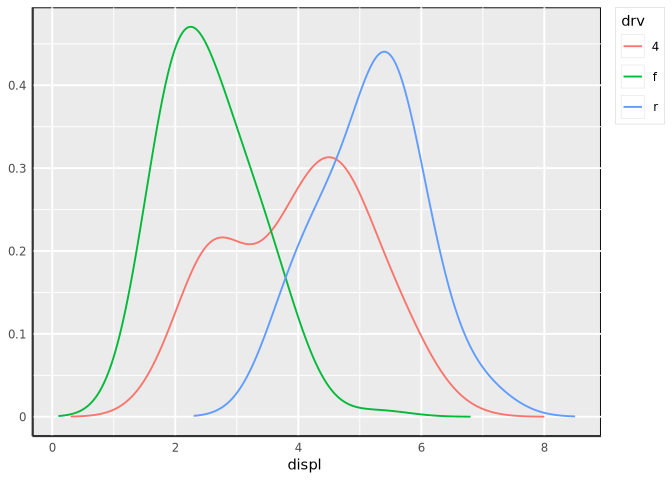

In [11]:
# User-specified bandwidth
ggplot(mpg, aes('displ', colour='drv')) + stat_density_common(bandwidth=.5)

## Creating a new geom

It's harder to create a new geom because you also need to know grid_py.
The key method is `draw_panel()` (one grob per panel) or `draw_group()`
(one grob per group).

### Inheriting from an existing Geom

The easiest approach is to inherit from an existing Geom and change defaults.
For example, creating a hollow polygon geom for convex hulls:

In [12]:
from ggplot2_py.geom import GeomPolygon, Mapping

class GeomPolygonHollow(GeomPolygon):
    """Polygon with no fill by default — ideal for convex hulls."""
    default_aes = Mapping(
        colour='black', fill=None, linewidth=0.5,
        linetype=1, alpha=None,
    )


def geom_chull(mapping=None, data=None, position='identity', **kwargs):
    """Convenience geom for convex hulls."""
    return Layer(
        stat=StatChull, geom=GeomPolygonHollow, data=data,
        mapping=mapping, position=position, params=kwargs,
    )

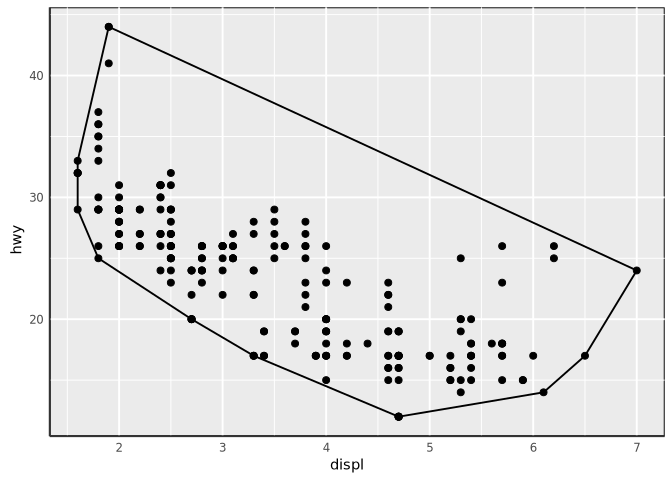

In [13]:
# No need to specify fill=None every time
ggplot(mpg, aes('displ', 'hwy')) + geom_point() + geom_chull()

## Creating your own theme

Themes govern how non-data elements of the plot are displayed.

### Overriding elements

When you add a `theme()` call, it modifies (inherits from) the existing theme.
Adding a complete theme (e.g. `theme_bw()`) replaces it entirely.

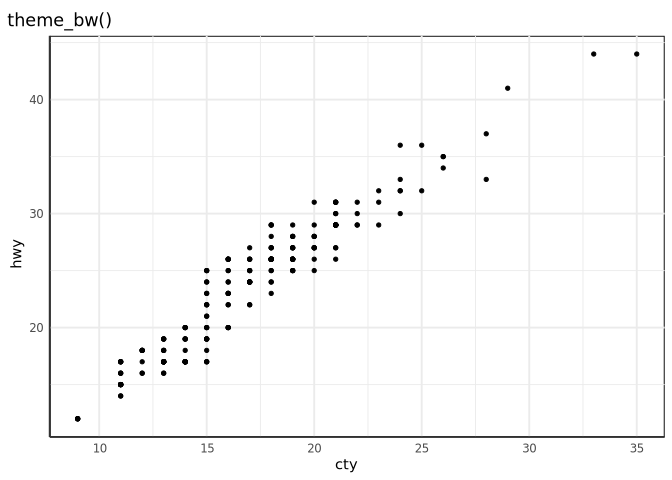

In [14]:
# Built-in complete themes
base = ggplot(mpg, aes('cty', 'hwy')) + geom_point(size=0.8)
base + theme_bw() + labs(title='theme_bw()')

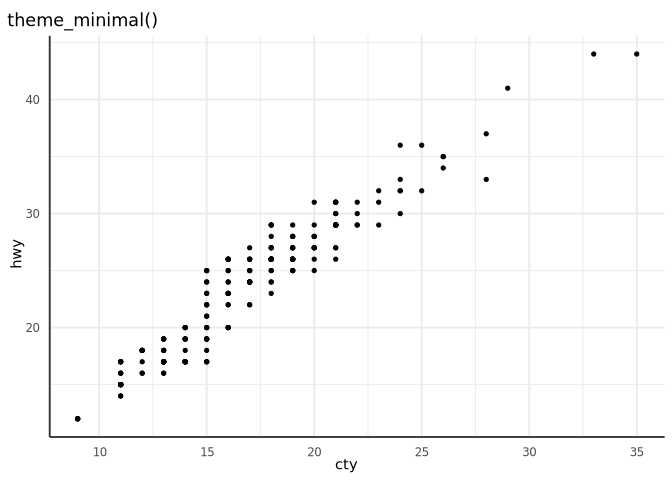

In [15]:
base + theme_minimal() + labs(title='theme_minimal()')

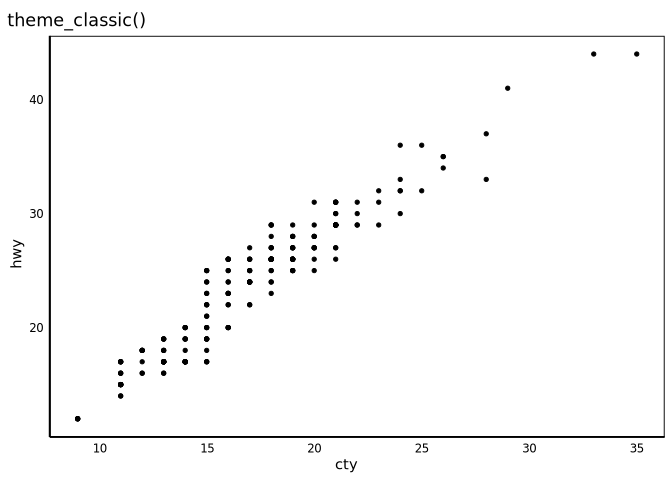

In [16]:
base + theme_classic() + labs(title='theme_classic()')

### Global elements

There are four elements that affect the global appearance: `line`, `rect`,
`text`, and `title`. These set default properties inherited by more
specific settings.

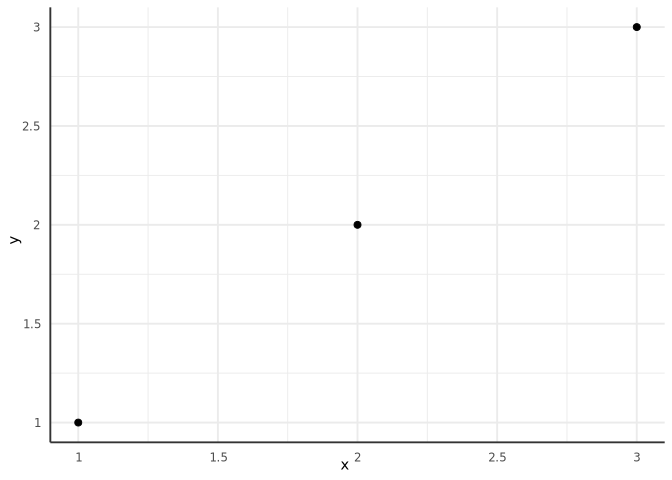

In [17]:
df = pd.DataFrame({'x': [1, 2, 3], 'y': [1, 2, 3]})
base2 = ggplot(df, aes('x', 'y')) + geom_point() + theme_minimal()
base2

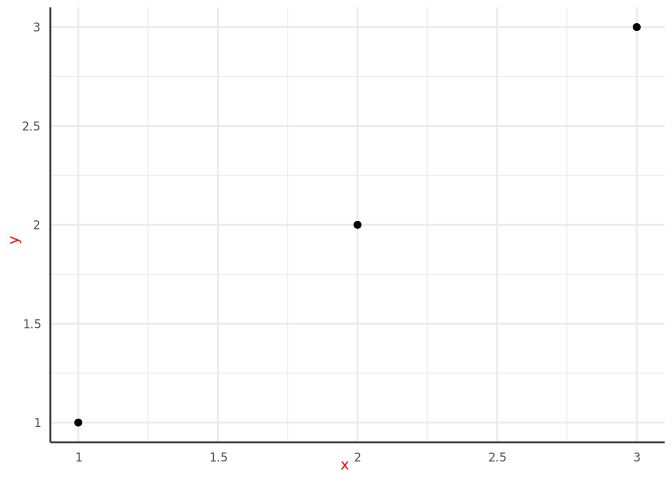

In [18]:
# Override the global text element to make all text red
base2 + theme(text=element_text(colour='red'))

### Fine-grained customisation

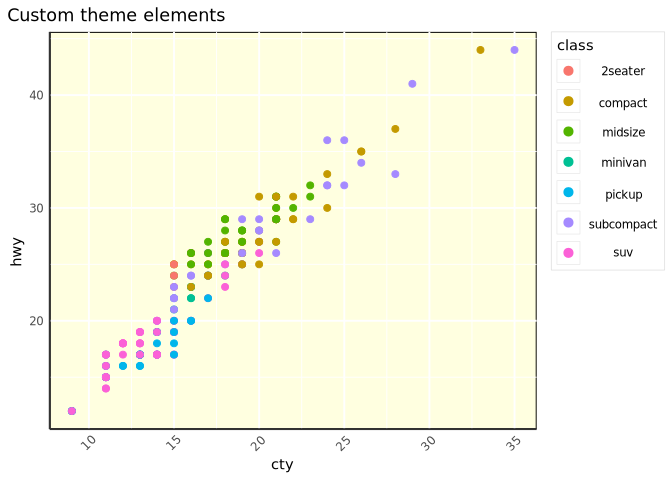

In [19]:
(
    ggplot(mpg, aes('cty', 'hwy', colour='class'))
    + geom_point()
    + theme(
        panel_background=element_rect(fill='lightyellow'),
        axis_text_x=element_text(angle=45, hjust=1),
    )
    + labs(title='Custom theme elements')
)

## Putting it all together

Custom stats, geoms, scales, facets, labels, and themes compose freely
via the `+` operator — this is the Grammar of Graphics in action.

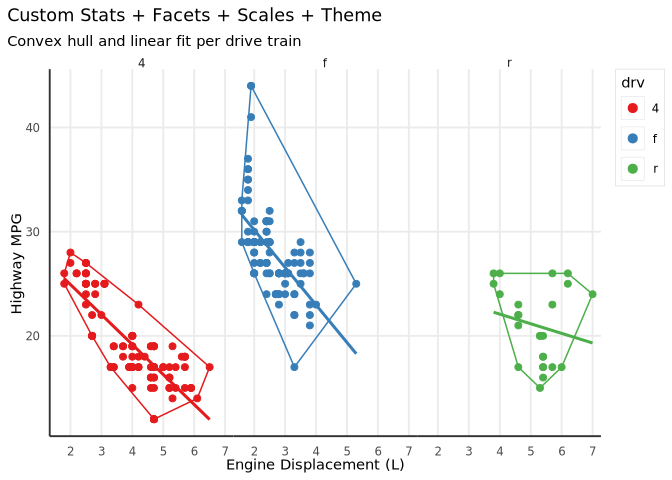

In [20]:
(
    ggplot(mpg, aes('displ', 'hwy', colour='drv'))
    + geom_point(size=1.5)
    + stat_chull(fill=None, linewidth=0.4)
    + stat_lm(linewidth=0.8)
    + facet_wrap('drv')
    + scale_colour_brewer(palette='Set1')
    + theme_minimal()
    + theme(panel_grid_minor=element_blank())
    + labs(
        title='Custom Stats + Facets + Scales + Theme',
        subtitle='Convex hull and linear fit per drive train',
        x='Engine Displacement (L)',
        y='Highway MPG',
    )
)